# 03 Train Symbolic SODT

Canonical symbolic stage of the thesis pipeline:
1. load the trained Faster R-CNN teacher,
2. export symbolic RoI datasets for `trainval` and `test`,
3. train one configured SODT with TAO on the exported `trainval` RoIs,
4. evaluate that trained SODT on the held-out `test` export.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

from neuro.config import NeuroConfig, NeuroTrainConfig
from neuro.faster_rcnn import NeuroFasterRCNN
from neuro.prepare_dataset import PCBDataset
from neuro.preprocess_dataset import test_preprocess
from symbolic.config import SymbolicTrainConfig
from symbolic.export import extract_dataset_from_teacher, summarize_symbolic_export
from symbolic.train import train_symbolic_tree, evaluate_heldout, load_symbolic_tree, prune_symbolic_tree
from util.artifacts import next_run_artifacts, latest_run_checkpoint
from util.config import load_yaml
from util.device import select_device

train_config = load_yaml(Path("neuro_train.yaml"), NeuroTrainConfig)
neuro_config = load_yaml(Path("neuro.yaml"), NeuroConfig)
symbolic_train_config = load_yaml(Path("symbolic_train.yaml"), SymbolicTrainConfig)

device = select_device(train_config["device"])
class_names = tuple(train_config["dataset"]["class_names"])

checkpoint_dir = Path("checkpoints") / "neuro"
checkpoint_path = latest_run_checkpoint(checkpoint_dir)
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

model = NeuroFasterRCNN(
    neuro_config=neuro_config,
    train_config=train_config,
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

symbolic_dir = Path("checkpoints") / "symbolic"
next_run = next_run_artifacts(symbolic_dir)
teacher_trainval_path = symbolic_dir / "teacher_trainval_mixed_bg.pt"
teacher_test_path = symbolic_dir / "teacher_test_mixed_bg.pt"
symbolic_checkpoint_path = next_run.checkpoint_path
symbolic_summary_path = next_run.metrics_path

checkpoint_path, class_names

(PosixPath('checkpoints/neuro/run1.pt'),
 ('open', 'short', 'mouse_bite', 'spur', 'pinhole', 'spurious_copper'))

In [2]:
trainval_dataset = PCBDataset(train_config, "trainval.txt")
trainval_dataset.add_preprocess(test_preprocess())

test_dataset = PCBDataset(train_config, "test.txt")
test_dataset.add_preprocess(test_preprocess())

symbolic_data_config = symbolic_train_config["data"]
storage_dtype = str(symbolic_data_config["storage_dtype"])

len(trainval_dataset), len(test_dataset)

(1000, 500)

In [3]:
extract_dataset_from_teacher(
    model=model,
    dataset=trainval_dataset,
    output_path=teacher_trainval_path,
    device=train_config["device"],
    storage_dtype=storage_dtype,
)
extract_dataset_from_teacher(
    model=model,
    dataset=test_dataset,
    output_path=teacher_test_path,
    device=train_config["device"],
    storage_dtype=storage_dtype,
)

teacher_trainval_path, teacher_test_path

Skipping teacher dataset extraction; found existing artifact at checkpoints/symbolic/teacher_trainval_mixed_bg.pt.
Skipping teacher dataset extraction; found existing artifact at checkpoints/symbolic/teacher_test_mixed_bg.pt.


(PosixPath('checkpoints/symbolic/teacher_trainval_mixed_bg.pt'),
 PosixPath('checkpoints/symbolic/teacher_test_mixed_bg.pt'))

In [4]:
trainval_manifest, trainval_overview, trainval_counts = summarize_symbolic_export(
    teacher_trainval_path,
    "trainval",
)
test_manifest, test_overview, test_counts = summarize_symbolic_export(
    teacher_test_path,
    "test",
)

display(pd.concat([trainval_overview, test_overview], ignore_index=True))
display(pd.concat([trainval_counts, test_counts], ignore_index=True))

,split,images,total_rois,background_rois,positive_rois,feature_shape,feature_cut,symbolic_target,proposal_source
0,trainval,1000,1000000,866399,133601,64x7x7,roi_align_pooled_grid,teacher_label,rpn_pre_detector_postprocess
1,test,500,500000,437291,62709,64x7x7,roi_align_pooled_grid,teacher_label,rpn_pre_detector_postprocess


,split,class_name,count
0,trainval,__background__,866399
1,trainval,open,26389
2,trainval,short,18847
3,trainval,mouse_bite,26843
4,trainval,spur,20739
5,trainval,pinhole,19709
6,trainval,spurious_copper,21074
7,test,__background__,437291
8,test,open,13536
9,test,short,9296


## Training

In [5]:
summary, training_state = train_symbolic_tree(
    export_path=teacher_trainval_path,
    output_path=symbolic_checkpoint_path,
    summary_path=symbolic_summary_path,
    config=symbolic_train_config,
)
summary = prune_symbolic_tree(
    **training_state,
    checkpoint_path=symbolic_checkpoint_path,
)
summary

Loading symbolic training export from checkpoints/symbolic/teacher_trainval_mixed_bg.pt...
Symbolic training data ready in 1s.

       Selected RoI Class Distribution       
---------------------------------------------
Class Name                |   Selected RoIs
---------------------------------------------
__background__            |         133,601
open                      |          26,389
short                     |          18,847
mouse_bite                |          26,843
spur                      |          20,739
pinhole                   |          19,709
spurious_copper           |          21,074

Loaded 267202 symbolic samples with 3136 raw RoI-pooled feature dimensions.
TAO consumes the full RoI Align feature vector. Symbolic sparsity comes only from L1 regularization and the tree structure.
Training one configured SODT on the configured trainval RoI set: depth=5, lambda=10, alpha=1.
Workload check: 15 TAO iterations and up to 465 LIBLINEAR node fits.
Each TAO iteration

TAO 15/15 nodes: 100%|██████████| 31/31 [01:27<00:00,  2.84s/it, iteration_done | mimic=0.9706 nz=39460]


=== Pruning Symbolic Tree ===
Tree: 267,202 RoIs, 31 internal nodes
Walking 31 internal nodes (reverse BFS)...
  Node 30 (depth 4): pruned — pure subtree (all leaves → __background__)
  Node 28 (depth 4): pruned — pure subtree (all leaves → __background__)
  Node 27 (depth 4): pruned — pure subtree (all leaves → __background__)
  Node 24 (depth 4): pruned — pure subtree (all leaves → short)
  Node 20 (depth 4): pruned — pure subtree (all leaves → __background__)
  Node 19 (depth 4): pruned — pure subtree (all leaves → __background__)
  Node 18 (depth 4): pruned — pure subtree (all leaves → open)
  Node 17 (depth 4): pruned — pure subtree (all leaves → __background__)
  Node 16 (depth 4): pruned — pure subtree (all leaves → __background__)
  Node 15 (depth 4): pruned — pure subtree (all leaves → __background__)
  Node 13 (depth 3): pruned — pure subtree (all leaves → __background__)
  Node 9 (depth 3): pruned — pure subtree (all leaves → __background__)
  Node 7 (depth 3): pruned — pure

Spatial grounding: 100%|██████████| 267202/267202 [01:29<00:00, 2989.35it/s]

mimic accuracy: 0.9706
nonzero weights: 4937
active nodes: 14
Saving checkpoint... done


{'export_path': 'checkpoints/symbolic/teacher_trainval_mixed_bg.pt',
 'output_path': 'checkpoints/symbolic/run5.pt',
 'metrics': {'mimic_accuracy': 0.9705503701319601,
  'macro_f1_vs_teacher': 0.9694003096885832,
  'per_class_agreement_vs_teacher': {'__background__': 0.962155971886438,
   'open': 0.9832884914168782,
   'short': 0.966625988220937,
   'mouse_bite': 0.9809261259918787,
   'spur': 0.9719369304209461,
   'pinhole': 0.9832056420924451,
   'spurious_copper': 0.9849103160292303},
  'mean_path_feature_count': 790.5917844926311,
  'median_path_feature_count': 828.0,
  'necessity_confidence_drop': 0.533313242060536,
  'necessity_prediction_flip_rate': 0.5194347347699493,
  'sufficiency_prediction_preservation': 1.0,
  'sufficiency_confidence_retention': 1.0,
  'evaluated_roi_count': 214351,
  'box_grounded_roi_overlap': 0.7497176998241257,
  'pointing_score': 0.7968239009848332,
  'energy_in_defect_ratio': 0.8228209736314666,
  'heatmap_entropy': 0.9163837339547132,
  'stability_

## Heldout Evaluation

In [6]:
heldout_eval = evaluate_heldout(
    export_path=teacher_test_path,
    checkpoint_path=symbolic_checkpoint_path,
)
heldout_eval

Loading heldout evaluation data from checkpoints/symbolic/teacher_test_mixed_bg.pt...
Loaded 500,000 samples in 1s
Evaluating on held-out set...


Spatial grounding: 100%|██████████| 500000/500000 [02:08<00:00, 3903.93it/s]


{'export_path': 'checkpoints/symbolic/teacher_test_mixed_bg.pt',
 'sample_count': 500000,
 'class_names': ('__background__',
  'open',
  'short',
  'mouse_bite',
  'spur',
  'pinhole',
  'spurious_copper'),
 'feature_shape': (64, 7, 7),
 'tree_depth': 5,
 'l1_lambda': 10.0,
 'sparsity_alpha': 1.0,
 'metrics': {'mimic_accuracy': 0.959696,
  'macro_f1_vs_teacher': 0.872112752046544,
  'per_class_agreement_vs_teacher': {'__background__': 0.9582314751504147,
   'open': 0.9674202127659575,
   'short': 0.9564328743545611,
   'mouse_bite': 0.9728107041770306,
   'spur': 0.9695969832665566,
   'pinhole': 0.9804134929270947,
   'spurious_copper': 0.9728704230696262},
  'mean_path_feature_count': 743.907242,
  'median_path_feature_count': 543.0,
  'necessity_confidence_drop': 0.23945438583254813,
  'necessity_prediction_flip_rate': 0.172342,
  'sufficiency_prediction_preservation': 1.0,
  'sufficiency_confidence_retention': 1.0,
  'evaluated_roi_count': 308258,
  'box_grounded_roi_overlap': 0.68

### Single SODT Student Metrics

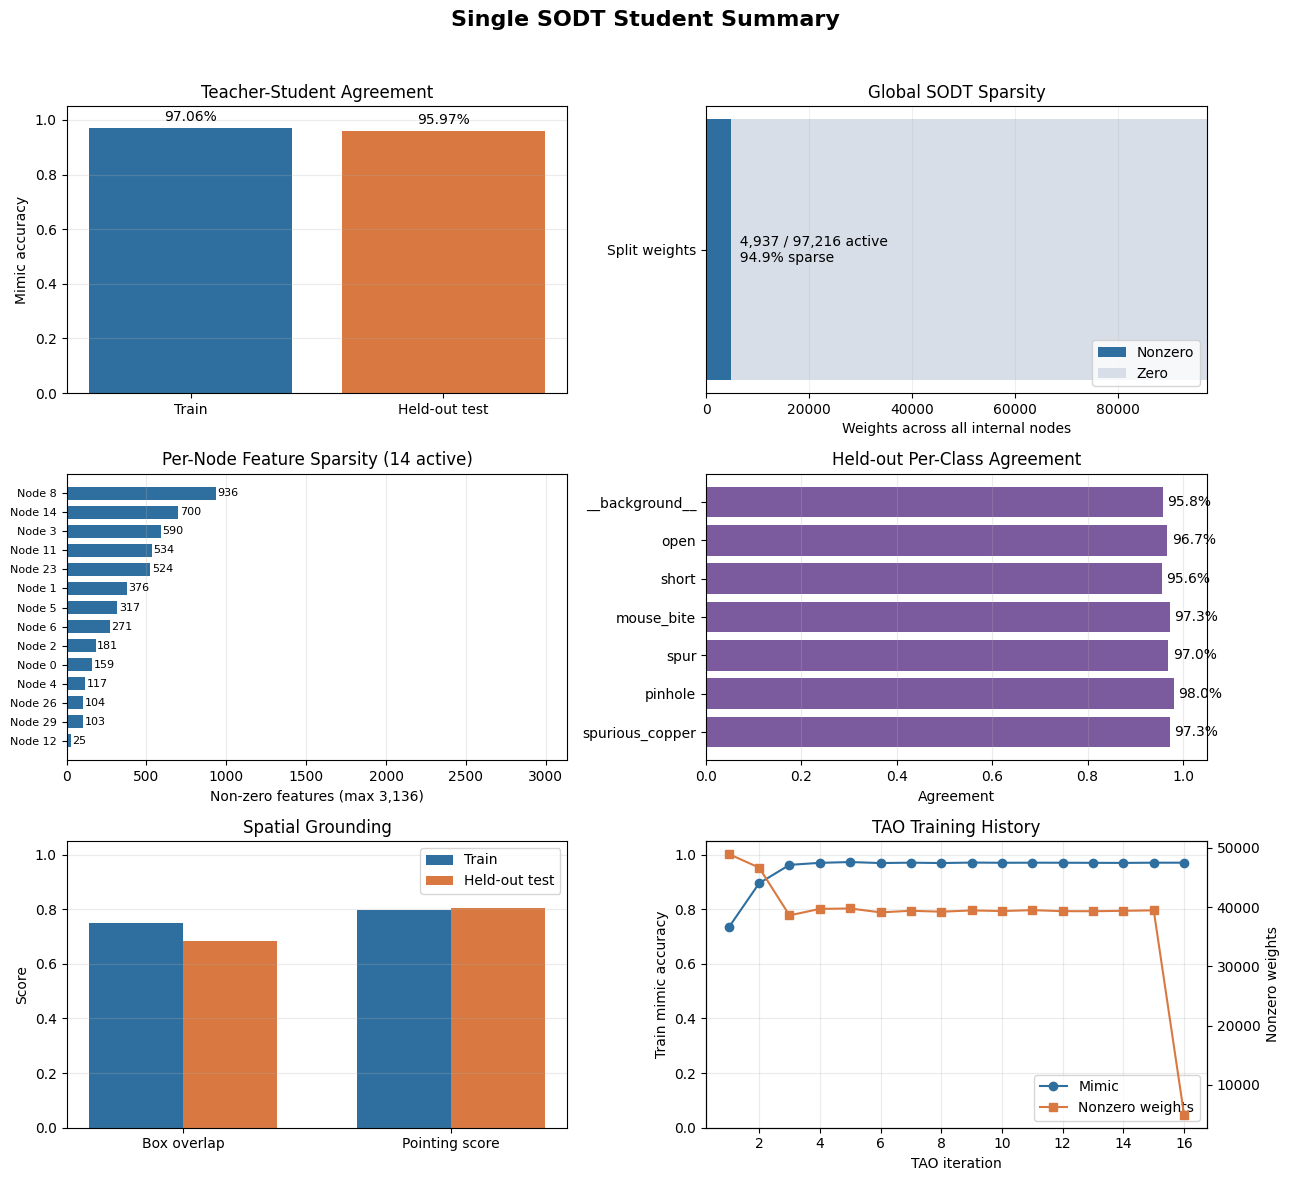

{'train_mimic_accuracy': 0.9705503701319601,
 'heldout_mimic_accuracy': 0.959696,
 'nonzero_weights': 4937,
 'total_split_weights': 97216,
 'global_weight_sparsity': 0.9492161784068466,
 'roi_feature_count': 3136}

In [7]:
train_metrics = summary["metrics"]
heldout_metrics = heldout_eval["metrics"]

feature_dim = int(np.prod(summary["feature_shape"]))
total_split_weights = train_metrics["num_internal_nodes"] * feature_dim
nonzero_weights = train_metrics["nonzero_weights"]
zero_weights = max(total_split_weights - nonzero_weights, 0)
weight_sparsity = zero_weights / max(total_split_weights, 1)

train_mimic = train_metrics["mimic_accuracy"]
test_mimic = heldout_metrics["mimic_accuracy"]
per_node_counts = load_symbolic_tree(symbolic_checkpoint_path).nonzero_weight_counts()
per_node_active = sorted(
    [(i, c) for i, c in enumerate(per_node_counts) if c > 0],
    key=lambda x: x[1], reverse=True,
)

class_agreement = heldout_metrics["per_class_agreement_vs_teacher"]
class_names_list = list(class_agreement.keys())
class_values = [class_agreement[name] for name in class_names_list]

history = pd.DataFrame(summary["history"])

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
fig.suptitle("Single SODT Student Summary", fontsize=16, fontweight="bold")

ax = axes[0, 0]
accuracy_labels = ["Train", "Held-out test"]
accuracy_values = [train_mimic, test_mimic]
accuracy_bars = ax.bar(accuracy_labels, accuracy_values, color=["#2F6F9F", "#D97941"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mimic accuracy")
ax.set_title("Teacher-Student Agreement")
ax.bar_label(
    accuracy_bars, labels=[f"{value:.2%}" for value in accuracy_values], padding=3
)
ax.grid(axis="y", alpha=0.25)

ax = axes[0, 1]
ax.barh(["Split weights"], [nonzero_weights], color="#2F6F9F", label="Nonzero")
ax.barh(
    ["Split weights"],
    [zero_weights],
    left=[nonzero_weights],
    color="#D7DEE8",
    label="Zero",
)
ax.set_xlim(0, total_split_weights)
ax.set_xlabel("Weights across all internal nodes")
ax.set_title("Global SODT Sparsity")
ax.text(
    nonzero_weights,
    0,
    f"  {nonzero_weights:,} / {total_split_weights:,} active\n  {weight_sparsity:.1%} sparse",
    va="center",
)
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.2)

ax = axes[1, 0]
node_labels = [f"Node {i}" for i, _ in per_node_active]
node_values = [c for _, c in per_node_active]
y_pos = np.arange(len(per_node_active))
ax.barh(y_pos, node_values, color="#2F6F9F", height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(node_labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, feature_dim)
ax.set_xlabel("Non-zero features (max {:,})".format(feature_dim))
ax.set_title("Per-Node Feature Sparsity ({} active)".format(len(per_node_active)))
for i, (_, c) in enumerate(per_node_active):
    ax.text(c + feature_dim * 0.003, i, f"{c:,}", va="center", fontsize=8)
ax.grid(axis="x", alpha=0.25)

ax = axes[1, 1]
y_positions = np.arange(len(class_names_list))
class_bars = ax.barh(y_positions, class_values, color="#7C5A9E")
ax.set_yticks(y_positions)
ax.set_yticklabels(class_names_list)
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel("Agreement")
ax.set_title("Held-out Per-Class Agreement")
ax.bar_label(class_bars, labels=[f"{value:.1%}" for value in class_values], padding=3)
ax.grid(axis="x", alpha=0.25)

ax = axes[2, 0]
spatial_metric_names = ["box_grounded_roi_overlap", "pointing_score"]
x = np.arange(len(spatial_metric_names))
bar_width = 0.35
train_spatial = [train_metrics[name] for name in spatial_metric_names]
test_spatial = [heldout_metrics[name] for name in spatial_metric_names]
ax.bar(
    x - bar_width / 2, train_spatial, width=bar_width, color="#2F6F9F", label="Train"
)
ax.bar(
    x + bar_width / 2,
    test_spatial,
    width=bar_width,
    color="#D97941",
    label="Held-out test",
)
ax.set_xticks(x)
ax.set_xticklabels(["Box overlap", "Pointing score"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Spatial Grounding")
ax.legend()
ax.grid(axis="y", alpha=0.25)

ax = axes[2, 1]
if not history.empty:
    ax.plot(
        history["iteration"],
        history["mimic_accuracy"],
        color="#2F6F9F",
        marker="o",
        label="Mimic",
    )
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("TAO iteration")
    ax.set_ylabel("Train mimic accuracy")
    ax.grid(alpha=0.25)
    ax_nonzero = ax.twinx()
    ax_nonzero.plot(
        history["iteration"],
        history["nonzero_weights"],
        color="#D97941",
        marker="s",
        label="Nonzero weights",
    )
    ax_nonzero.set_ylabel("Nonzero weights")
    lines, labels = ax.get_legend_handles_labels()
    extra_lines, extra_labels = ax_nonzero.get_legend_handles_labels()
    ax.legend(lines + extra_lines, labels + extra_labels, loc="lower right")
ax.set_title("TAO Training History")

fig.tight_layout(rect=[0, 0, 1, 0.96])
display(Markdown("### Single SODT Student Metrics"))
plt.show()

{
    "train_mimic_accuracy": train_mimic,
    "heldout_mimic_accuracy": test_mimic,
    "nonzero_weights": nonzero_weights,
    "total_split_weights": total_split_weights,
    "global_weight_sparsity": weight_sparsity,
    "roi_feature_count": feature_dim,
}